## Running kinGEMs Pipeline on $E. coli$ iML1515 Model

In [2]:

%load_ext autoreload
%autoreload 2

import os
import sys
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('distributed').setLevel(logging.ERROR)
try:
    import gurobipy
    gurobipy.setParam('OutputFlag', 0)
except ImportError:
    pass
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import cobra # type: ignore
import numpy as np # type: ignore
from datetime import datetime
import random
from cobra.io import write_sbml_model # type: ignore
import cobra as cb

# Add parent directory to Python path
sys.path.append(os.path.abspath('..'))

# Import kinGEMs components
import kinGEMs
from kinGEMs.dataset import load_model, convert_to_irreversible, prepare_model_data, retrieve_sequences, map_metabolites, merge_substrate_sequences, process_merged_data_with_folds, process_kcat_predictions, assign_kcats_to_model, format_kcats_like_gpr, annotate_model_with_kcat_and_gpr
from kinGEMs.dataset_modelseed import prepare_modelseed_model_data
from kinGEMs.modeling.optimize import run_optimization_with_dataframe, validate_enzyme_constraints
from kinGEMs.modeling.tuning import simulated_annealing
from kinGEMs.modeling.fva import flux_variability_analysis, plot_flux_variability, plot_cumulative_fvi_distribution, flux_variability_analysis_parallel
from kinGEMs.plots import analyze_kcat_changes

Set parameter Username
Academic license - for non-commercial use only - expires 2026-02-25
Academic license - for non-commercial use only - expires 2026-02-25


2025-10-02 11:58:04.569 | INFO     | kinGEMs.config:<module>:12 - PROJ_ROOT path is: C:\Users\Rana\OneDrive\Documents\GitHub\kinGEMs_v2


### Set your GEM name here

In [3]:

# === Configuration ===
organism_strain_GEMname = "382_genome_cpd03198" # Update this
organism = "E coli" # Update this 
run_id = f"{organism_strain_GEMname}_{datetime.today().strftime('%Y%m%d')}_{random.randint(1000, 9999)}"

# Directories
data_dir = "../data"
biolog_dir = os.path.join(data_dir, "Biolog experiments")
raw_data_dir = os.path.join(data_dir, "raw")
interim_data_dir = os.path.join(data_dir, "interim")
interim_data_dir_spec = os.path.join(interim_data_dir, f"{organism_strain_GEMname}")
processed_data_dir = os.path.join(data_dir, "processed")
processed_data_dir_spec = os.path.join(processed_data_dir, f"{organism_strain_GEMname}")
CPIPred_data_dir = os.path.join(interim_data_dir, "CPI-Pred predictions")
results_dir = os.path.join(os.getcwd(), "results")
tuning_results_dir = os.path.join(results_dir, "tuning_results", run_id)
os.makedirs(tuning_results_dir, exist_ok=True)

# Input files
model_path = os.path.join(raw_data_dir, f"{organism_strain_GEMname}.xml") # Update this
predictions_csv_path = os.path.join(CPIPred_data_dir, f"X06A_kinGEMs_{organism_strain_GEMname}_predictions.csv")
metadata_path = os.path.join(biolog_dir, f"rxnXgenes_382_genome.csv") # Update this data\Biolog experiments\rxnXgenes_382_genome.csv
biolog_experiments_path = os.path.join(biolog_dir, f"FBA_results.xlsx")

# Output files
substrates_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_substrates.csv")
sequences_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_sequences.csv")
merged_data_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_merged_data.csv")
processed_data_output = os.path.join(processed_data_dir_spec, f"{organism_strain_GEMname}_processed_data.csv")

# Load your model 
model = cobra.io.read_sbml_model(model_path)

# Print the whole objective
print("Objective expression:", model.objective.expression)
print("Direction:", model.objective.direction)  # 'max' or 'min'

# List all reactions with a non‐zero coefficient
obj_rxns = {rxn.id: rxn.objective_coefficient
            for rxn in model.reactions
            if rxn.objective_coefficient != 0}

print("Objective reaction(s) and coefficient(s):")
for rxn_id, coeff in obj_rxns.items():
    print(f"  {rxn_id} → {coeff}")

obj_rxn_id = next(rxn.id for rxn in model.reactions if rxn.objective_coefficient != 0)
print("Primary objective reaction:", obj_rxn_id)

# Simulation parameters
biomass_reaction = obj_rxn_id # Update this
enzyme_upper_bound = 0.15


'382_genome' is not a valid SBML 'SId'.


Objective expression: 1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Direction: max
Objective reaction(s) and coefficient(s):
  EX_cpd11416_c0 → 1.0
Primary objective reaction: EX_cpd11416_c0


In [4]:
model.optimize()

,fluxes,reduced_costs
rxn00001_c0,0.000000,-2.627932e-02
rxn00003_c0,0.000000,1.751955e-02
rxn00006_c0,0.000000,0.000000e+00
rxn00007_c0,0.000000,-1.970949e-02
rxn00010_c0,0.000000,-2.627932e-02
...,...,...
rxn06046_c0,0.000000,-6.938894e-18
rxn09428_c0,0.051410,-1.387779e-17
rxn19870_c0,0.000000,0.000000e+00
rxn31225_c0,0.000000,-0.000000e+00


### Step 1: Preparing and processing model data

In [5]:

print("=== Step 1: Preparing model data ===")
irrev_model, substrate_df, sequences_df = prepare_modelseed_model_data(
    model_path=model_path,
    substrates_output=substrates_output,
    sequences_output=sequences_output,
    organism=organism,
    metadata_dir=biolog_dir  # Pass the directory, not the file
)


=== Step 1: Preparing model data ===


SBML errors in validation, check error log for details.
COBRA errors in validation, check error log for details.
COBRA errors in validation, check error log for details.


'382_genome' is not a valid SBML 'SId'.


Loaded model with 3011 reactions and 2360 metabolites
Extracted 9023 substrate-reaction-direction pairs
Mapped metabolites to SMILES (8412 found)
Gene: NODE_1_3110591_3110064
    [qseqid: UniRef90_Q8FAG0] [db: UniRef] [accession: Q8FAG0]Gene: NODE_1_3110591_3110064
    [qseqid: UniRef90_Q8FAG0] [db: UniRef] [accession: Q8FAG0]  [UniProtKB: HIT]
Gene: NODE_1_2417380_2415695
    [qseqid: sp|P08142|ILVB_ECOLI] [db: UniProtKB] [accession: P08142]  [UniProtKB: HIT]
Gene: NODE_1_2417380_2415695
    [qseqid: sp|P08142|ILVB_ECOLI] [db: UniProtKB] [accession: P08142]  [UniProtKB: HIT]
Gene: NODE_1_3372496_3374217
    [qseqid: sp|P00893|ILVI_ECOLI] [db: UniProtKB] [accession: P00893]  [UniProtKB: HIT]
Gene: NODE_1_3372496_3374217
    [qseqid: sp|P00893|ILVI_ECOLI] [db: UniProtKB] [accession: P00893]  [UniProtKB: HIT]
Gene: NODE_1_2510003_2511634
    [qseqid: sp|P08142|ILVB_ECOLI] [db: UniProtKB] [accession: P08142]  [UniProtKB: HIT]
Gene: NODE_1_2510003_2511634
    [qseqid: sp|P08142|ILVB_ECOLI]

### Step 2: Merging substrate and sequence data

In [15]:

print("=== Step 2: Merging substrate and sequence data ===")

# substrate_df = pd.read_csv(substrates_output)
# sequences_df = pd.read_csv(sequences_output)
# model = load_model(model_path)

merged_data = merge_substrate_sequences(
    substrate_df=substrate_df,
    sequences_df=sequences_df,
    model=irrev_model,
    output_path=merged_data_output
)


=== Step 2: Merging substrate and sequence data ===


In [16]:
merged_data

,Reactions,Reaction_partners,Direction,CMPD_SMILES,DB Name,Single_gene,GPR_rules,SEQ,kcat
0,rxn00001_c0,cpd00001,forward,O,H2O,NODE_1_3110591_3110064,NODE_1_3110591_3110064,MSLLNVPAGKDLPEDIYVVIEIPANADPIKYEIDKESGALFVDRFM...,0.345000
1,rxn00001_c0,cpd00012,forward,O=P([O-])([O-])OP(=O)([O-])O,PPi,NODE_1_3110591_3110064,NODE_1_3110591_3110064,MSLLNVPAGKDLPEDIYVVIEIPANADPIKYEIDKESGALFVDRFM...,0.417624
2,rxn00003_c0,cpd00011,forward,O=C=O,CO2,NODE_1_2417380_2415695,(NODE_1_2417380_2415695 or NODE_1_3372496_3374...,MASSGTTSTRKRFTGAEFIVHFLEQQGIKIVTGIPGGSILPVYDAL...,0.612316
3,rxn00003_c0,cpd00011,forward,O=C=O,CO2,NODE_1_3372496_3374217,(NODE_1_2417380_2415695 or NODE_1_3372496_3374...,MEMLSGAEMVVRSLIDQGVKQVFGYPGGAVLDIYDALHTVGGIDHV...,0.934122
4,rxn00003_c0,cpd00011,forward,O=C=O,CO2,NODE_1_2510003_2511634,(NODE_1_2417380_2415695 or NODE_1_3372496_3374...,MASSGTTSTRKRFTGAEFIVHFLEQQGIKIVTGIPGGSILPVYDAL...,0.317108
...,...,...,...,...,...,...,...,...,...
19468,rxn31225_c0,cpd00010,reverse,CC(C)(COP(=O)([O-])OP(=O)([O-])OC[C@H]1O[C@@H]...,CoA,NaN,NaN,NaN,0.576053
19469,rxn31225_c0,cpd11494,reverse,NaN,Acetyl-ACP,NaN,NaN,NaN,0.323309
19470,rxn90019_c0,cpd00001,forward,O,H2O,NaN,NaN,NaN,0.759065
19471,rxn90019_c0,cpd00002,forward,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,ATP,NaN,NaN,NaN,0.916299


In [17]:
# === Debug: Inspect processed_data and df_FBA structure ===
print('processed_data columns:', list(processed_data.columns))
print('processed_data head:')
print(processed_data.head())

if df_FBA is not None:
    print('df_FBA columns:', list(df_FBA.columns))
    print('df_FBA head:')
    print(df_FBA.head())
else:
    print('df_FBA is None')

processed_data columns: ['Reactions', 'Reaction_partners', 'Direction', 'CMPD_SMILES', 'DB Name', 'Single_gene', 'GPR_rules', 'SEQ', 'Unnamed: 0', 'kcat_y', 'pred_value_0', 'pred_value_1', 'pred_value_2', 'pred_value_3', 'pred_value_4', 'kcat_mean', 'kcat_std', 'kcat_cv', 'kcat_min', 'kcat_max']
processed_data head:
     Reactions Reaction_partners Direction                   CMPD_SMILES  \
0  rxn00001_c0          cpd00001   forward                             O   
1  rxn00001_c0          cpd00001   forward                             O   
2  rxn00001_c0          cpd00012   forward  O=P([O-])([O-])OP(=O)([O-])O   
3  rxn00003_c0          cpd00011   forward                         O=C=O   
4  rxn00003_c0          cpd00011   forward                         O=C=O   

  DB Name             Single_gene  \
0     H2O  NODE_1_3110591_3110064   
1     H2O  NODE_1_3110591_3110064   
2     PPi  NODE_1_3110591_3110064   
3     CO2  NODE_1_2417380_2415695   
4     CO2  NODE_1_2417380_2415695   

  

In [18]:
# === Fix: Ensure processed_data has a 'kcat' column for constraints ===
if 'kcat_mean' in processed_data.columns:
    processed_data['kcat'] = processed_data['kcat_mean']
    print("[INFO] Set processed_data['kcat'] = processed_data['kcat_mean']")
elif 'kcat_y' in processed_data.columns:
    processed_data['kcat'] = processed_data['kcat_y']
    print("[INFO] Set processed_data['kcat'] = processed_data['kcat_y']")
else:
    print("[WARNING] No kcat_mean or kcat_y column found in processed_data! 'kcat' will not be set.")

print('processed_data columns after fix:', list(processed_data.columns))
print('First 5 kcat values:', processed_data['kcat'].head())

[INFO] Set processed_data['kcat'] = processed_data['kcat_mean']
processed_data columns after fix: ['Reactions', 'Reaction_partners', 'Direction', 'CMPD_SMILES', 'DB Name', 'Single_gene', 'GPR_rules', 'SEQ', 'Unnamed: 0', 'kcat_y', 'pred_value_0', 'pred_value_1', 'pred_value_2', 'pred_value_3', 'pred_value_4', 'kcat_mean', 'kcat_std', 'kcat_cv', 'kcat_min', 'kcat_max', 'kcat']
First 5 kcat values: 0     33.438627
1     33.438627
2    222.602795
3     11.050746
4     11.050746
Name: kcat, dtype: float64


### Step 3: Processing CPI-Pred kcat values

In [19]:

print("=== Step 3: Processing CPI-Pred kcat values & annotating model ===")
processed_data = process_kcat_predictions(
    merged_df=merged_data,
    predictions_csv_path=predictions_csv_path,
    output_path=processed_data_output
)

irrev_model = annotate_model_with_kcat_and_gpr(
    model=irrev_model,
    df=processed_data
)


=== Step 3: Processing CPI-Pred kcat values & annotating model ===


## Step 4: Optimization (FBA Sanity Check + kinGEMs)

make sure code below works first

In [ ]:
from cobra.util.array import create_stoichiometric_matrix
import pyomo.environ as pyo
from pyomo.environ import *  # noqa: F403
from pyomo.opt import SolverFactory, SolverStatus, TerminationCondition

# 1) Load your COBRApy model
model = irrev_model
# Or if you have a JSON:
# model = cobra.io.load_json_model("path/to/your_model.json")

# 2) Extract S, bounds, and objective coefficients
#    S will be shape (m metabolites × n reactions)
S = create_stoichiometric_matrix(model)  

metabolites = list(model.metabolites)
reactions   = list(model.reactions)
m, n = S.shape

lb = np.array([rxn.lower_bound for rxn in reactions])
ub = np.array([rxn.upper_bound for rxn in reactions])
c  = np.array([rxn.objective_coefficient for rxn in reactions])

print("objective_coefficient: ", [rxn.objective_coefficient for rxn in reactions])
print("same but with our option: ", {r.id: (1.0 if r.id == biomass_reaction else 0.0) for r in model.reactions})
print("original option:", {r.id: r.objective_coefficient for r in model.reactions})

# 3) Build the Pyomo model
pyomo_model = ConcreteModel()
pyomo_model.I = Set(initialize=range(m))  # metabolite indices
pyomo_model.J = Set(initialize=range(n))  # reaction indices

# flux variables v[j] with the same bounds
def v_bounds(mod, j):
    return (float(lb[j]), float(ub[j]))
pyomo_model.v = Var(pyomo_model.J, domain=Reals, bounds=v_bounds)

# mass‐balance constraints: for each metabolite i, sum_j S[i,j]*v[j] == 0
def mass_balance_rule(mod, i):
    return sum(S[i, j] * mod.v[j] for j in mod.J) == 0
pyomo_model.mass_balance = Constraint(pyomo_model.I, rule=mass_balance_rule)

# objective: maximize cᵀ v
pyomo_model.obj = Objective(
    expr = sum(c[j] * pyomo_model.v[j] for j in pyomo_model.J),
    sense = maximize
)

# 4) Solve it with GLPK (or another LP solver you've installed)
solver = SolverFactory('glpk')
result = solver.solve(pyomo_model, tee=False)

# 5) Extract Pyomo solution
pyomo_fluxes = np.array([value(pyomo_model.v[j]) for j in range(n)])
pyomo_obj     = value(pyomo_model.obj)

# 6) Solve with COBRApy’s built-in optimizer for comparison
cobra_solution = model.optimize()
cobra_fluxes   = np.array([cobra_solution.fluxes[rxn.id] for rxn in reactions])
cobra_obj      = cobra_solution.objective_value

# 7) Verify they match
print(f" COBRA optimize() objective: {cobra_obj:.6g}")
print(f"   Pyomo objective:        {pyomo_obj:.6g}")
print(" Max |flux_pyomo – flux_cobra| =", np.max(np.abs(pyomo_fluxes - cobra_fluxes)))


objective_coefficient:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 

In [12]:
print("=== Step 4: Running optimization with kcat constraints ===")
(solution_value, df_FBA, gene_sequences_dict, _)=run_optimization_with_dataframe(
    model=irrev_model, 
    processed_df=processed_data, 
    objective_reaction=biomass_reaction, 
    enzyme_upper_bound=enzyme_upper_bound, 
    enzyme_ratio=True, 
    maximization=True, 
    multi_enzyme_off=False, 
    isoenzymes_off=False, 
    promiscuous_off=False, 
    complexes_off=False,
    output_dir=None, 
    save_results=False,
    print_reaction_conditions=True)

print("Biomass value: ", solution_value)

=== Step 4: Running optimization with kcat constraints ===
[MW ERROR] Gene: NODE_1_208956_208099 | Sequence: 'MKNILSIQSHVVFGHAGNSXAEFPXRRMGVNVWPLNTVQFSNHTQYPEKWTGCVMXAEHITEIVDGIAAIGKLAQCDAVLSGYLGSAEQGRRIVDIVKKVKQANPNAWYFCDPVMGHPEKGCIVPPEVSGVLCEDALPISDIIAPNLLELETLAGGATLHNVDQCVKAARQLCQQGPKIVLVKHLSRAGFRHDRFEMLLVTADHSWHVSRPLVDFGERQPVGVGDLTSGLMLVDLLKGVELKTALEHVAAAVYEVMLKTKEMNEYELQLVAAQDQMVHPTHNFCATQLD' | Error: ''X'' is not a valid unambiguous letter for protein
[MW ERROR] Gene: NODE_2_51691_52971 | Sequence: 'MESLEIIPFVQKXTASVSVPGSKSISNRALILATLSKXSVRLQGMLVSEDVELMRKALLSLGVKIDEGNDQNEFIVHGCGGIFDVKEQDIFVGNAGTVARFLTALLATQIDGIYRLDGTAAMRKRPMLELIEALENLGCQFEFLEKKGCFPFVMQTRGXKNATWNVDATQSSQVLSALLMIAPAINKKTTIQYYGGTVSEPFVDLTLKMIQIFSTQEKCSAEKKDSEISISSDGYRANDFTYEIEPDATAASYFLTLPIVTNGNCRVLGISKIMDQGDAAYEEVLEEIGFRIIEDSSGITSTFVGGAEKVEFDFNAISDTFMTLAAITPILPKGVKIYGIAHTRKQETDRVKAMAIELRKLGQKVIETEDSLEIYPNLEFLKQKASXGISIDTYYDHRFAMSFGILGCFDLFSNGQPWLTINNPLCCAKTFPDFFXKLKIARLESHG' | Error: ''X'' is not a valid unambiguou

In [13]:
# === Debug: Inspect enzyme constraint mapping and usage ===
import numpy as np

# 1. Print kcat statistics from processed_data
if 'kcat' in processed_data.columns:
    kcats = processed_data['kcat'].dropna().values
    print(f"[DEBUG] kcat stats: min={np.min(kcats):.2e}, max={np.max(kcats):.2e}, median={np.median(kcats):.2e}, mean={np.mean(kcats):.2e}, n={len(kcats)}")
else:
    print("[DEBUG] No 'kcat' column in processed_data!")

# 2. Print a few enzyme constraint mappings (first 5 rows)
if 'Reactions' in processed_data.columns and 'Single_gene' in processed_data.columns and 'kcat' in processed_data.columns:
    print("[DEBUG] Example enzyme constraint mappings (reaction, gene, kcat):")
    print(processed_data[['Reactions','Single_gene','kcat']].head(5))
else:
    print("[DEBUG] processed_data missing expected columns for mapping debug.")

# 3. Print enzyme usage for a few reactions/genes from df_FBA if available
if df_FBA is not None and 'enzyme_usage' in df_FBA.columns:
    print("[DEBUG] Example enzyme usage (first 5):")
    print(df_FBA[['Reactions','Single_gene','enzyme_usage']].head(5))
else:
    print("[DEBUG] df_FBA missing or missing 'enzyme_usage' column.")

[DEBUG] No 'kcat' column in processed_data!
[DEBUG] processed_data missing expected columns for mapping debug.
[DEBUG] df_FBA missing or missing 'enzyme_usage' column.


### Step 5: Simulated Annealing

=== Step 5: Running simulated annealing ===
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607

--- Iteration 1 ---
Current biomass = 3.633023e-01
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Proposed biomass = 4.388913e-01

--- Iteration 2 ---
Current biomass = 4.388913e-01
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Proposed biomass = 5.116831e-01

--- Iteration 3 ---
Current biomass = 5.116831e-01
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Proposed biomass = 5.439807e-01

--- Iteration 4 ---
Current biomass = 5.439807e-01
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Proposed biomass = 5.671344e-01

--- Iteration 5 ---
Current biomass = 5.671344e-01
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Proposed biomass = 5.868813e-01

--- Iteration 6 ---
Current biomass = 5.868813e-01
Mode

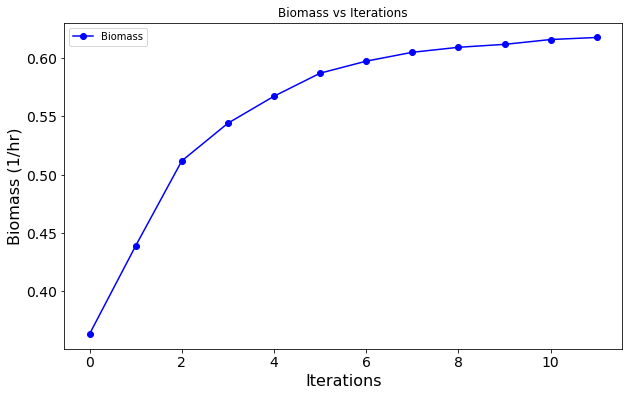

In [59]:

print("=== Step 5: Running simulated annealing ===")
temperature = 1.0
cooling_rate = 0.95
min_temperature = 0.01
max_iterations = 100
max_unchanged_iterations = 4
change_threshold = 0.009
biomass_goal = 1

kcat_dict, top_targets, df_new, iterations, biomasses, df_FBA = simulated_annealing(
    model=irrev_model,
    processed_data=processed_data,
    biomass_reaction=biomass_reaction,
    objective_value=biomass_goal,
    gene_sequences_dict=gene_sequences_dict,      # ← new
    output_dir=tuning_results_dir,
    enzyme_fraction=enzyme_upper_bound,
    temperature=temperature,
    cooling_rate=cooling_rate,
    min_temperature=min_temperature,
    max_iterations=max_iterations,
    max_unchanged_iterations=max_unchanged_iterations,
    change_threshold=change_threshold
)

print(f"Final biomass: {biomasses[-1]:.4f}")
print(f"Improvement: {(biomasses[-1] - biomasses[0]) / biomasses[0] * 100:.1f}%")
print("Top 10 enzymes by mass contribution:")
print(top_targets[['Reactions','Single_gene','enzyme_mass']])


In [ ]:
import pandas as pd

# Save df_new to the tuning_results_dir if not already saved
df_new_path = os.path.join(tuning_results_dir, "df_new.csv")
df_new.to_csv(df_new_path, index=False)

# Paths for kcat_dict and output
kcat_dict_path = os.path.join(tuning_results_dir, "kcat_dict.csv")
final_info_path = os.path.join(tuning_results_dir, "final_model_info.csv")

# Load the dataframes
df_new = pd.read_csv(df_new_path)
kcat_dict_df = pd.read_csv(kcat_dict_path)

# Ensure kcat_dict_df has columns: reaction_gene, kcat_value (adjust if needed)
if 'reaction_gene' not in kcat_dict_df.columns:
    kcat_dict_df.columns = ['reaction_gene', 'kcat_value']

# Create reaction_gene key in df_new for matching
df_new['reaction_gene'] = df_new['Reactions'].astype(str) + '_' + df_new['Single_gene'].astype(str)

# Merge kcat values into df_new
df_new = df_new.merge(kcat_dict_df, on='reaction_gene', how='left')
df_new.rename(columns={'kcat_value': 'kcat_tuned'}, inplace=True)

# Save to results folder
df_new.to_csv(final_info_path, index=False)
print(f'Saved merged DataFrame with kcat_tuned column to {final_info_path}')

### Step 6: Experimental Comparative Analysis

In [ ]:
# 1) Experimental table (re-use exp_df from earlier)
# # read the “Ecoli” sheet
ecoli_df = pd.read_excel(
    biolog_experiments_path,
    sheet_name="Ecoli",
    engine="openpyxl",
)

# peek at the data
# print(ecoli_df.shape)
# print(ecoli_df.head())

exp_df = ecoli_df
# 2) Define which substrates to disable except the one being tested
blocked_cpds = [
    "cpd00224","cpd00122","cpd00609","cpd00108","cpd00794","cpd00138",
    "cpd00588","cpd00751","cpd00164","cpd00222","cpd00154","cpd00314",
    "cpd00105","cpd00396","cpd00082","cpd00027","cpd00179","cpd03198",
    "cpd00184","cpd00208","cpd00249","cpd01262","cpd00182","cpd00246",
    "cpd00054","cpd00020","cpd00280","cpd00832","cpd00232","cpd00276"
]

# 3) Helper: simulate enzyme-constrained growth for one substrate

def simulate_enzyme_rate(
    base_model: Model,
    processed_df: pd.DataFrame,
    biomass_reaction: str,
    gene_sequences_dict: dict,
    cpd_id: str,
    uptake_rate: float = 10.0
) -> float:
    # deep copy so original model not modified
    mdl = deepcopy(base_model)
    # disable uptake for all blocked substrates
    for cpd in blocked_cpds:
        if cpd.lower() == cpd_id.lower():
            continue
        ex_name = f"EX_{cpd}_e0"
        if ex_name in mdl.reactions:
            mdl.reactions.get_by_id(ex_name).lower_bound = 0.0
    # enable uptake for the tested C-source
    target_ex = f"EX_{cpd_id}_e0"
    if target_ex not in mdl.reactions:
        raise KeyError(f"Exchange {target_ex} not found")
    mdl.reactions.get_by_id(target_ex).lower_bound = -abs(uptake_rate)
    # run enzyme-constrained FBA
    sol_val, df_FBA, _, _ = run_optimization_with_dataframe(
        model=mdl,
        processed_df=processed_df,
        objective_reaction=biomass_reaction,
        enzyme_upper_bound=enzyme_upper_bound,
        enzyme_ratio=True,
        maximization=True,
        multi_enzyme_off=False,
        isoenzymes_off=False,
        promiscuous_off=False,
        complexes_off=False,
        output_dir=None,
        save_results=False,
        print_reaction_conditions=False
    )
    return sol_val

# 4) Baseline on glucose
glc = "cpd00027"
glc_rate = simulate_enzyme_rate(
    base_model=irrev_model,
    processed_df=processed_data,
    biomass_reaction=biomass_reaction,
    gene_sequences_dict=gene_sequences_dict,
    cpd_id=glc,
    uptake_rate=100.0
)
print(f"Enzyme-constrained glucose growth: {glc_rate:.4f}")

# 5) Loop over each substrate and record normalized rates
results = []
for row in exp_df.itertuples():
    cpd = row.cpd
    print(f"=== Testing substrate: {cpd} ===")
    try:
        rate = simulate_enzyme_rate(
            base_model=irrev_model,
            processed_df=processed_data,
            biomass_reaction=biomass_reaction,
            gene_sequences_dict=gene_sequences_dict,
            cpd_id=cpd,
            uptake_rate=100.0
        )
        print(f"Predicted enzyme-constrained rate: {rate:.4f}")
    except Exception as e:
        rate = None
        print(f"⚠️ Warning for {cpd}: {e}")
    norm = rate/glc_rate if rate is not None and glc_rate > 0 else None
    if norm is not None:
        print(f"Normalized rate (relative to glucose): {norm:.4f}")
    else:
        print("Normalized rate: N/A")
    print(f"Experimental value: {row.exp_value:.4f}")
    results.append({
        'cpd': cpd,
        'ec_rate': rate,
        'norm_rate': norm,
        'exp_value': row.exp_value
    })

enz_df = pd.DataFrame(results)
# 6) Merge and view
comp_df = exp_df.merge(enz_df, on='cpd')
print("=== Summary Comparison ===")
print(comp_df)

# 7) Plot comparison
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter(comp_df['exp_value'], comp_df['norm_rate'], s=50)
plt.xlabel('Experimental value (normalized by glucose)')
plt.ylabel('Model normalized enzyme-constrained rate')
plt.title('Enzyme-constrained FBA vs. experimental')
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 7: Save Final Model

In [ ]:
# Define output path for final GEM
model_output_dir = os.path.join("models")
os.makedirs(model_output_dir, exist_ok=True)
model_output_path = os.path.join(model_output_dir, f"{run_id}.xml")

# After simulated annealing
model_with_kcats = assign_kcats_to_model(irrev_model, df_new)

# Preview:
format_kcats_like_gpr(model_with_kcats.reactions.get_by_id("PGI"))


# Save the final irreversible model
write_sbml_model(model_with_kcats, model_output_path)

print(f"Final GEM saved to: {model_output_path}")